# K-mouflage: comparison without / with quintessence potential

Model: power-law $K(X) = -1 + X + K_0 X^m$, exponential coupling $\beta$.

Potential: $V(\phi) = V_0\, e^{-\lambda \phi / M_{\rm Pl}}$ (canonical quintessence).

Parameters explored: $V_0 = 0.7$, $\lambda \in \{0, 1, 3, 10\}$.

Note: every model below (including the bare one) is calibrated so that
$\Omega_{\rm DE}(z=0) = 1 - \Omega_{m0} - \Omega_{r0}$ — see `calibrate_M4_tilde`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from kmouflage.solver             import KMouflageBackground, CosmologicalParams
from kmouflage.models.k_functions import make_powerlaw_K
from kmouflage.models.couplings   import make_exponential_coupling
from kmouflage.models.potential   import make_exponential_potential
from kmouflage.calibrate_M4       import calibrate_M4_tilde
from kmouflage.verify             import verify

## Common parameters

In [2]:
K_MODEL  = make_powerlaw_K(K0=1, m=3)
COUPLING = make_exponential_coupling(beta=0.1)
COSMO    = CosmologicalParams(H0_input=67.36, Omega_m0=0.25)

SOLVER_KW = dict(model=K_MODEL, coupling=COUPLING, cosmo=COSMO)

V0   = 0.7
LAMS = [0, 1, 3, 10]

## Integration

Bare model = no potentiel $ V_0=0 $

In [3]:
TARGET_ODE = 1.0 - COSMO.Omega_m0 - COSMO.Omega_r0

def run_calibrated(potential=None, verbose=False):
    bg = KMouflageBackground(**SOLVER_KW, potential=potential)
    calibrate_M4_tilde(bg, target_Omega_DE=TARGET_ODE, tol=1e-5, verbose=verbose)
    return bg

s_bare = run_calibrated(potential=None, verbose=True)

s_quints = []
M4_calibrated = []
for lam in LAMS:
    bg = run_calibrated(potential=make_exponential_potential(V0=V0, lam=lam), verbose=True)
    s_quints.append(bg)
    M4_calibrated.append(bg.M4_tilde)

# summary
print(f"\n{'':─<60}")
print(f"target Omega_DE(0) = {TARGET_ODE:.6f}\n")
print(f"Bare model     : M4_tilde = {s_bare.M4_tilde:.6f}  "
      f"Omega_DE(0) = {float(s_bare.Omega_de_def(0.0)):.5f}  "
      f"w_DE(0) = {float(s_bare.w_de_def(0.0)):.4f}")
for lam, sq, m4 in zip(LAMS, s_quints, M4_calibrated):
    print(f"lambda = {lam:<5}  M4_tilde = {m4:.6f}"
          f"  Omega_DE(0) = {float(sq.Omega_de_def(0.0)):.5f}"
          f"  w_DE(0) = {float(sq.w_de_def(0.0)):.4f}")


[calibrate_M4_tilde]  target=0.749916  tol=1.0e-05
─────────────────────────────────────────────────────
  it          M4_tilde     Omega_DE(0)            err
─────────────────────────────────────────────────────
   0      0.1000000000      0.04830428    -7.0161e-01
   1      3.0000000000      0.80866416    +5.8748e-02
   2      2.7759354857      0.79593463    +4.6019e-02
   3      2.0157764726      0.73653002    -1.3386e-02
   4      2.1870674486      0.75273695    +2.8210e-03
   5      2.1572528120      0.75006027    +1.4427e-04
   6      2.1556629535      0.74991592    -8.3270e-08
   7      2.1556638706      0.74991600    +4.7865e-11
   8      2.1556638656      0.74991600    -4.0648e-10
─────────────────────────────────────────────────────
[brentq converged]  it=9  M4_tilde=2.1556638706  Omega_DE(0)=0.74991600  err=+4.7865e-11


[calibrate_M4_tilde]  target=0.749916  tol=1.0e-05
─────────────────────────────────────────────────────
  it          M4_tilde     Omega_DE(0)            

## Common redshift grid

In [4]:
z  = np.linspace(0, 10, 4000)
N  = np.log(1.0 / (1.0 + z))
N0 = 0.0

colors = ["C1", "C2", "C3", "C4"]
labels = [f"with potential λ={l}" for l in LAMS]

## 1 — Scalar field equation of state $w_\phi(z)$

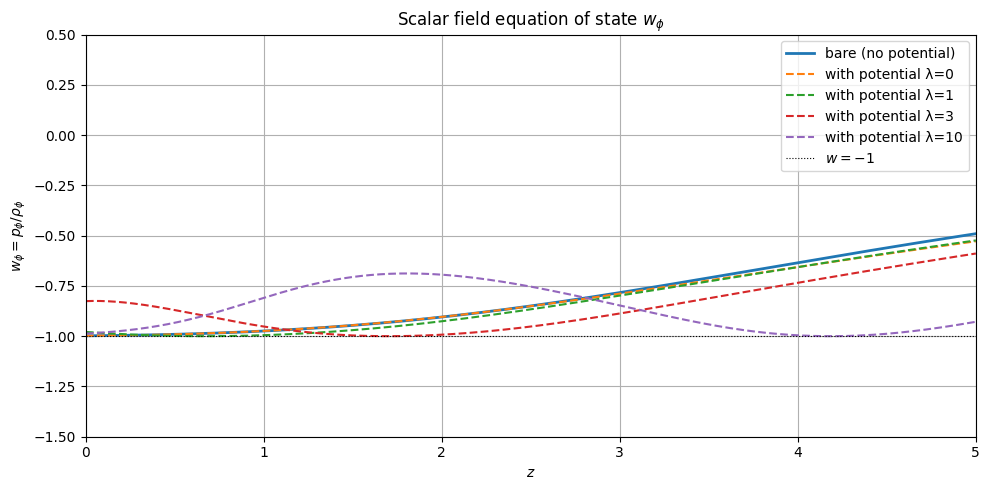

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, s_bare.w_phi(N), color="C0", lw=2, label="bare (no potential)")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, sq.w_phi(N), color=c, ls="--", label=lb)

ax.axhline(-1, color="k", lw=0.8, ls=":", label=r"$w=-1$")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_\phi = p_\phi / \rho_\phi$")
ax.set_title(r"Scalar field equation of state $w_\phi$")
ax.set_xlim(0, 5)
ax.set_ylim(-1.5, 0.5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 2 — Dark energy equation of state $w_{\rm DE}(z)$

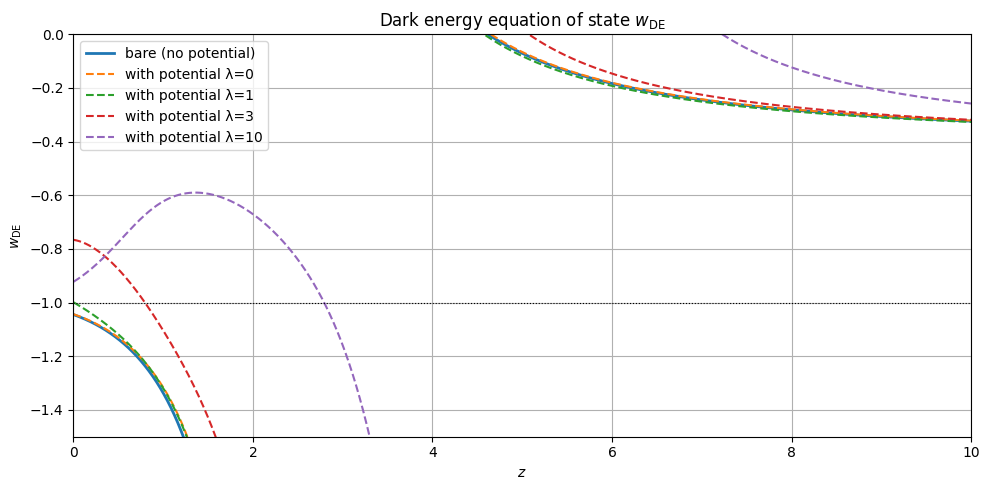

In [6]:
def safe_w(solver, N_grid):
    # Mask points where rho_de changes sign (w = p/rho diverges).
    rho = solver.rho_de_def(N_grid)
    w   = solver.w_de_def(N_grid)
    sign = np.sign(rho)
    bad  = (sign != np.roll(sign, 1)) | (sign != np.roll(sign, -1))
    return np.where(bad, np.nan, w)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, safe_w(s_bare, N), color="C0", lw=2, label="bare (no potential)")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, safe_w(sq, N), color=c, ls="--", label=lb)

ax.axhline(-1, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$w_{\rm DE}$")
ax.set_title(r"Dark energy equation of state $w_{\rm DE}$")
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 0.0)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 3 — Density parameters $\Omega_i(z)$

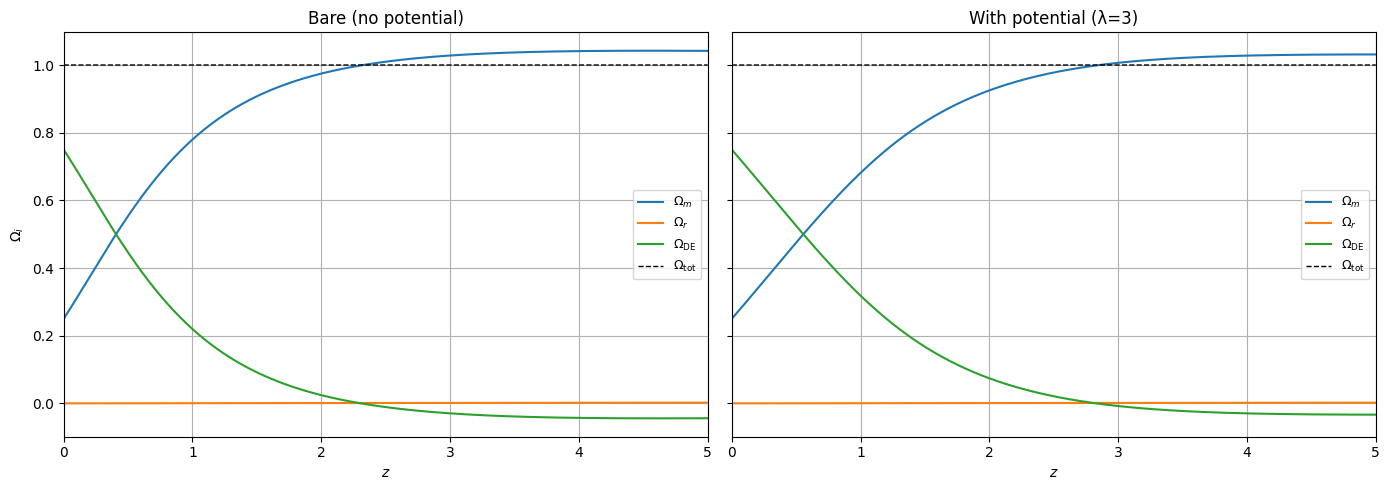

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

idx = 2  # LAMS[idx] -- a representative "with potential" case
solvers = [s_bare, s_quints[idx]]
titles  = ["Bare (no potential)", f"With potential (λ={LAMS[idx]})"]

for ax, s, title in zip(axes, solvers, titles):
    ax.plot(z, s.Omega_m(N),      label=r"$\Omega_m$",   color="C0")
    ax.plot(z, s.Omega_r(N),      label=r"$\Omega_r$",   color="C1")
    ax.plot(z, s.Omega_de_def(N), label=r"$\Omega_{\rm DE}$", color="C2")
    tot = s.Omega_m(N) + s.Omega_r(N) + s.Omega_de_def(N)
    ax.plot(z, tot, "k--", lw=1, label=r"$\Omega_{\rm tot}$")
    ax.set_xlabel(r"$z$")
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True)
    ax.set_xlim(0, 5)

axes[0].set_ylabel(r"$\Omega_i$")

plt.tight_layout()
plt.show()

## 4 — Hubble rate deviation $\Delta H / H_{\rm bare}$

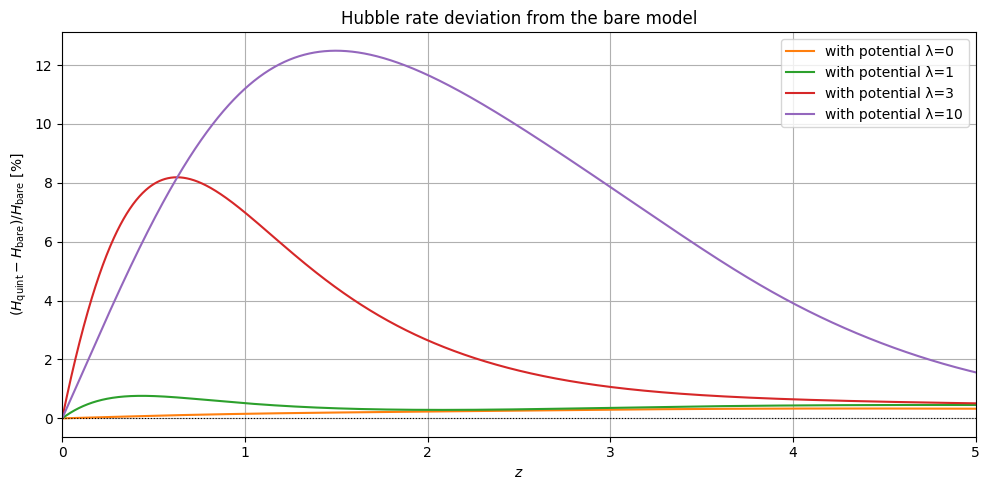

In [8]:
H0_km  = COSMO.H0_input
H_bare = s_bare.E_conf(N) * (1.0 + z) * H0_km

fig, ax = plt.subplots(figsize=(10, 5))
for sq, c, lb in zip(s_quints, colors, labels):
    H_q = sq.E_conf(N) * (1.0 + z) * H0_km
    ax.plot(z, (H_q - H_bare) / H_bare * 100, color=c, label=lb)

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(H_{\rm quint} - H_{\rm bare})/H_{\rm bare}$ [%]")
ax.set_title("Hubble rate deviation from the bare model")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 5 — Hubble rate deviation from $\Lambda$CDM

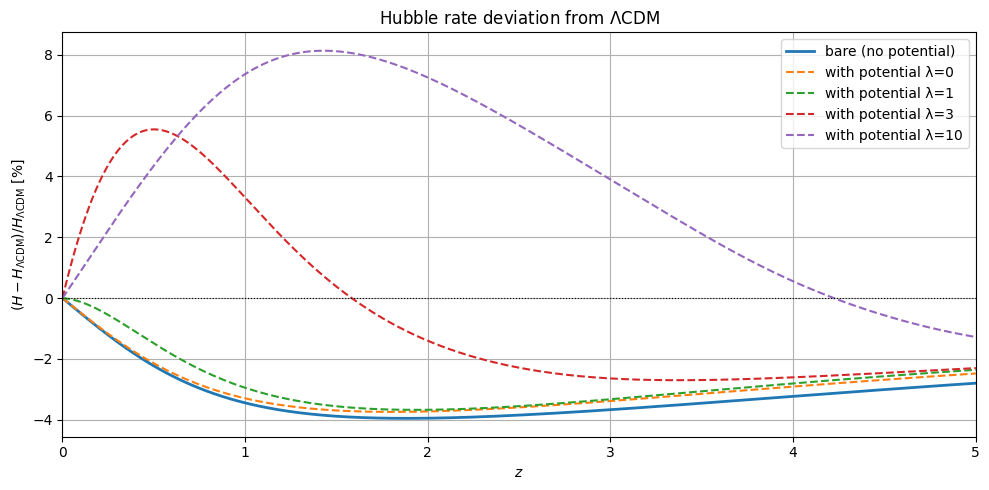

In [9]:
Omega_L0 = 1.0 - COSMO.Omega_m0 - COSMO.Omega_r0
H_lcdm = COSMO.H0_input * np.sqrt(
    COSMO.Omega_m0 * (1.0 + z)**3
    + COSMO.Omega_r0 * (1.0 + z)**4
    + Omega_L0
)

H0_km  = COSMO.H0_input
H_bare = s_bare.E_conf(N) * (1.0 + z) * H0_km

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, (H_bare - H_lcdm) / H_lcdm * 100,
        color="C0", lw=2, label="bare (no potential)")
for sq, c, lb in zip(s_quints, colors, labels):
    H_q = sq.E_conf(N) * (1.0 + z) * H0_km
    ax.plot(z, (H_q - H_lcdm) / H_lcdm * 100, color=c, ls="--", label=lb)

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(H - H_{\Lambda\rm CDM})/H_{\Lambda\rm CDM}$ [%]")
ax.set_title(r"Hubble rate deviation from $\Lambda$CDM")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6 — Scalar field evolution $\phi(z)$

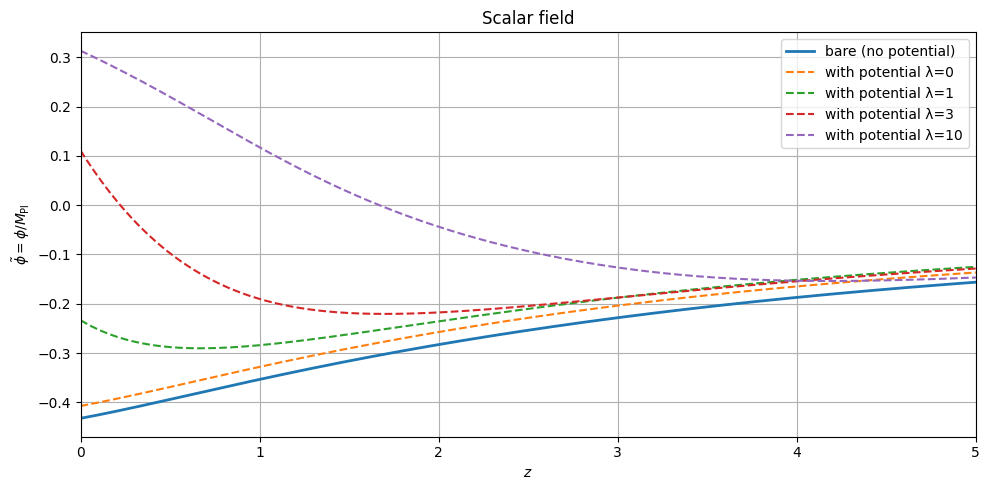

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, s_bare.phi(N), color="C0", lw=2, label="bare (no potential)")
for sq, c, lb in zip(s_quints, colors, labels):
    ax.plot(z, sq.phi(N), color=c, ls="--", label=lb)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\tilde{\phi} = \phi / M_{\rm Pl}$")
ax.set_title("Scalar field")
ax.set_xlim(0, 5)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 7 — Quintessence potential $V(\phi(z))$

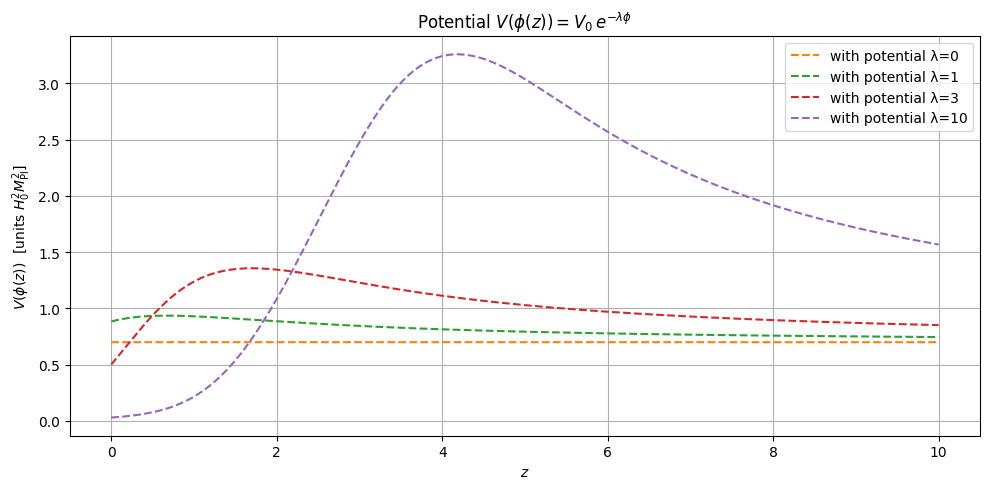

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for sq, lam, c, lb in zip(s_quints, LAMS, colors, labels):
    V_z = V0 * np.exp(-lam * sq.phi(N))
    ax.plot(z, V_z, color=c, ls="--", label=lb)

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$V(\phi(z))$  [units $H_0^2 M_{\rm Pl}^2$]")
ax.set_title(r"Potential $V(\phi(z)) = V_0\,e^{-\lambda\phi}$")

ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 8 — $f\sigma_8(z)$: K-mouflage vs $\Lambda$CDM vs DESI DR1

In [12]:
from kmouflage.growth import KmouflageGrowth, LCDMGrowth
from scipy.interpolate import interp1d

SIGMA8_0 = 0.811   # Planck normalization

DESI_POINTS = [
    ("PV",   0.070, 0.450, 0.055),
    ("BGS",  0.295, 0.417, 0.080),
    ("LRG1", 0.510, 0.439, 0.038),
    ("LRG2", 0.706, 0.460, 0.036),
    ("LRG3", 0.930, 0.439, 0.038),
    ("ELG2", 1.317, 0.482, 0.057),
    ("QSO",  1.491, 0.435, 0.100),
]
DESI_COLS = ["#7c3aed","#16a34a","#2563eb","#0891b2","#d97706","#dc2626","#9333ea"]

def add_fsigma8(r, sigma8_0=SIGMA8_0):
    r["fsigma8"] = r["f"] * sigma8_0 * r["Dp"]
    return r

# per-model plot styles
_names  = ["bare"] + [f"λ={l}" for l in LAMS]
_cols   = ["C0"]   + list(colors[:len(LAMS)])
_ls     = ["-"]    + ["--"] * len(LAMS)

COLORS_G = {"ΛCDM": "k"}
LS_MAP   = {"ΛCDM": "-"}
LW_MAP   = {"ΛCDM": 1.5}
for _n, _c, _l in zip(_names, _cols, _ls):
    COLORS_G[_n] = _c
    LS_MAP[_n]   = _l
    LW_MAP[_n]   = 2.0 if _n == "bare" else 1.5

# ΛCDM reference
lcdm_g = LCDMGrowth(Omega_m0=COSMO.Omega_m0, Omega_r0=COSMO.Omega_r0, N_points=2000)
rl = add_fsigma8(lcdm_g.run(verbose=False))

# K-mouflage bare
growth_results = {"ΛCDM": rl}
print("── Growth: bare")
growth_results["bare"] = add_fsigma8(KmouflageGrowth(s_bare, N_points=2000).run(verbose=True))

# K-mouflage + potential, one per λ
for lam, sq in zip(LAMS, s_quints):
    name = f"λ={lam}"
    print(f"\n── Growth: {name}")
    growth_results[name] = add_fsigma8(KmouflageGrowth(sq, N_points=2000).run(verbose=True))

── Growth: bare
[Kmouflage] N_eq=-7.998  (z_eq=2975)
[Kmouflage] N_MDE=-2.998  (z_MDE=19, 5.0 e-folds après a_eq)
[Kmouflage] CI check à N_MDE :
             Ω_r/Ω_m = 0.0067  (attendu ≪ 1)
             μ_K     = 0.996860  (attendu ≈ 1)
             F       = 1.007999  (attendu ≈ 1)
[Kmouflage] f(z=0)=0.45475 | D+(z=0)=1.00000 | Ω_m(z=0)=0.25000 | μ_K(z=0)=0.93667 | γ(z=0)=1.65954     | f(N_ini) =1.0

── Growth: λ=0
[Kmouflage] N_eq=-7.998  (z_eq=2975)
[Kmouflage] N_MDE=-2.998  (z_MDE=19, 5.0 e-folds après a_eq)
[Kmouflage] CI check à N_MDE :
             Ω_r/Ω_m = 0.0067  (attendu ≪ 1)
             μ_K     = 0.997314  (attendu ≈ 1)
             F       = 1.006869  (attendu ≈ 1)
[Kmouflage] f(z=0)=0.45591 | D+(z=0)=1.00000 | Ω_m(z=0)=0.25000 | μ_K(z=0)=0.94137 | γ(z=0)=1.65782     | f(N_ini) =1.0

── Growth: λ=1
[Kmouflage] N_eq=-7.998  (z_eq=2975)
[Kmouflage] N_MDE=-2.998  (z_MDE=19, 5.0 e-folds après a_eq)
[Kmouflage] CI check à N_MDE :
             Ω_r/Ω_m = 0.0067  (attendu ≪ 1)
  

/tmp/ipykernel_11410/4168738929.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


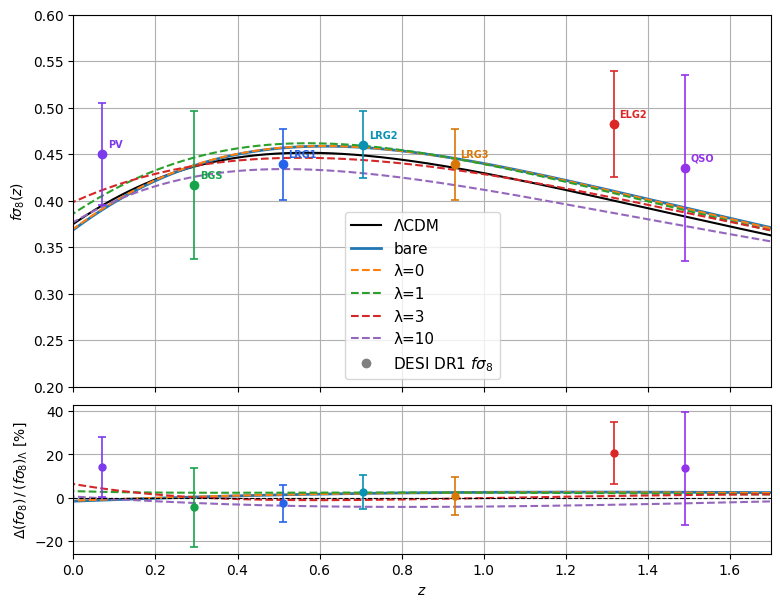

In [13]:
from matplotlib.lines import Line2D

fs8_lcdm_itp = interp1d(rl["z"], rl["fsigma8"], bounds_error=False, fill_value="extrapolate")

fig, (ax_f, ax_rat) = plt.subplots(
    2, 1, figsize=(9, 7),
    gridspec_kw={"height_ratios": [3, 1.2], "hspace": 0.07},
    sharex=True,
)

for name, rk in growth_results.items():
    c, ls, lw = COLORS_G[name], LS_MAP[name], LW_MAP[name]
    z_k = rk["z"]
    ax_f.plot(z_k, rk["fsigma8"], color=c, ls=ls, lw=lw, label=name)
    if name != "ΛCDM":
        dev = (rk["fsigma8"] - fs8_lcdm_itp(z_k)) / (np.abs(fs8_lcdm_itp(z_k)) + 1e-30) * 100
        ax_rat.plot(z_k, dev, color=c, ls=ls, lw=lw)

for (label, z_pt, fs8, err), col_pt in zip(DESI_POINTS, DESI_COLS):
    ax_f.errorbar(z_pt, fs8, yerr=err,
                  fmt="o", color=col_pt, capsize=3, capthick=1.2,
                  elinewidth=1.2, markersize=6, zorder=5)
    ax_f.annotate(label, xy=(z_pt, fs8), xytext=(4, 5),
                  textcoords="offset points", fontsize=7,
                  color=col_pt, fontweight="bold")

    fs8_ref      = fs8_lcdm_itp(z_pt)
    desi_dev     = (fs8 - fs8_ref) / (np.abs(fs8_ref) + 1e-30) * 100
    desi_dev_err = err              / (np.abs(fs8_ref) + 1e-30) * 100
    ax_rat.errorbar(z_pt, desi_dev, yerr=desi_dev_err,
                    fmt="o", color=col_pt, capsize=3, capthick=1.2,
                    elinewidth=1.2, markersize=5, zorder=5)

plt.setp(ax_f.get_xticklabels(), visible=False)
ax_f.set_ylabel(r"$f\sigma_8(z)$")
ax_f.set_xlim(0, 1.7)
ax_f.set_ylim(0.2, 0.6)
ax_f.grid(True)

desi_h = Line2D([0], [0], marker="o", color="gray", linestyle="None",
                markersize=6, label=r"DESI DR1 $f\sigma_8$")
handles = [l for l in ax_f.get_lines() if l.get_label() in COLORS_G] + [desi_h]
ax_f.legend(handles=handles, fontsize=11)

ax_rat.axhline(0, color="k", lw=0.8, ls="--")
ax_rat.set_xlabel(r"$z$")
ax_rat.set_ylabel(r"$\Delta(f\sigma_8)\,/\,(f\sigma_8)_\Lambda$ [%]")
ax_rat.grid(True)

plt.tight_layout()
plt.show()

## 9 — Verification report

In [14]:
print("=== Bare model ===")
verify(s_bare)

for lam, sq in zip(LAMS, s_quints):
    print(f"\n=== With potential λ={lam} ===")
    verify(sq)

    print(" Omega_m(z=0) = ", float(sq.Omega_m(0.0)))

    sum_omega = sq.Omega_m(N) + sq.Omega_r(N) + sq.Omega_de_def(N)
    err = np.max(np.abs(sum_omega - 1.0))
    print(f"max|sum Omega_i - 1| = {err:.3e}")
    tol = 1e-10
    if np.all(np.abs(sum_omega - 1.0) < tol):
        print("Sum of density parameters equal to 1 within numerical precision, for all N.")
    else:
        n_bad = np.sum(np.abs(sum_omega - 1.0) >= tol)
        print(f"{n_bad} points where the sum differs from 1 beyond the tolerance of {tol}.")

=== Bare model ===

══════════════════════════════════════════════════════════════
  VERIFICATION REPORT
  Model   : power-law (K0=1, m=3)
  Coupling: exponential (β=0.1)
══════════════════════════════════════════════════════════════

  Observational constraints
  ──────────────────────────────────────────────────────────────
  |ε_F| < 0.1  (BBN/G_eff)                max = +8.285e-02  [PASS]
  |α·φ̃′| ≤ 0.2·H₀  at z=0                val = +6.774e-03  [PASS]

  Numerical consistency
  ──────────────────────────────────────────────────────────────
  φ̃′ = ũ·E_conf  (conformal time)        max_rel = 9.999e-13  [PASS]

  Stability conditions
  ──────────────────────────────────────────────────────────────
  No ghost   Z_eff > 0                    min = +1.012e+00  [PASS]
  No gradient  Z > 0                      min = +1.003e+00  [PASS]
  Non-singular  |det M| > 0               min = 2.142e+00  [PASS]

  Initial conditions  (z_ini = 1.0e+05)
  ──────────────────────────────────────────────